In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

| **Feature**               | **Description**                                                                 |
|---------------------------|---------------------------------------------------------------------------------|
| `VendorID`                | Code indicating the provider associated with the trip record.                  |
| `tpep_pickup_datetime`    | Timestamp when the meter was engaged (trip start).                             |
| `tpep_dropoff_datetime`   | Timestamp when the meter was disengaged (trip end).                            |
| `passenger_count`         | Number of passengers in the vehicle (driver-entered).                          |
| `trip_distance`           | Distance of the trip in miles.                                                 |
| `RatecodeID`              | Final rate code in effect at the end of the trip.                              |
| `store_and_fwd_flag`      | Whether the trip record was stored before being sent (Y/N).                    |
| `PULocationID`            | TLC Taxi Zone ID for the pickup location.                                      |
| `DOLocationID`            | TLC Taxi Zone ID for the dropoff location.                                     |
| `payment_type`            | Numeric code for how the passenger paid.                                       |
| `fare_amount`             | Time-and-distance fare calculated by the meter.                                |
| `extra`                   | Miscellaneous extras and surcharges.                                           |
| `mta_tax`                 | $0.50 MTA tax triggered based on the metered rate in use.                      |
| `tip_amount`              | Tip amount (populated for credit card payments only).                          |
| `tolls_amount`            | Total tolls paid during the trip.                                              |
| `improvement_surcharge`   | $0.30 surcharge added at the flag drop (since 2015).                           |
| `total_amount`            | Total amount charged to the passenger (excluding cash tips).                   |
| `congestion_surcharge`    | Surcharge applied for trips involving congestion zones at specific times.      |


In [2]:
data = pd.read_csv(
    "Taxi_Datset.csv",
    parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"],
    date_format="%m/%d/%Y %I:%M:%S %p",
    low_memory=False
)
data.head(3)
#2m 24.5s

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238.0,239.0,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239.0,238.0,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238.0,238.0,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5


In [3]:
df = data.copy()
# Filter invalid or zero-distance trips
df = df[df["trip_distance"] > 0]

# Drop rows with missing essential fields
df = df.dropna(subset=["tpep_pickup_datetime", "PULocationID"])

# Drop rows with invalid or missing pickup datetimes
df = df.dropna(subset=["tpep_pickup_datetime"])

# Filter to January 2019 – February 2020
df = df[
    (df["tpep_pickup_datetime"] >= "2019-01-01") &
    (df["tpep_pickup_datetime"] < "2020-03-01")
]

### Temporal aggregation
# Round to the nearest hour
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.floor("h")

# Group by hour and pickup location
demand = df.copy().groupby(["pickup_hour", "PULocationID"]).size().reset_index(name="trip_count")

# Preview
print(demand.head())


          pickup_hour  PULocationID  trip_count
0 2019-12-31 13:00:00         142.0           1
1 2019-12-31 13:00:00         143.0           1
2 2019-12-31 13:00:00         161.0           1
3 2019-12-31 14:00:00          50.0           1
4 2019-12-31 14:00:00          74.0           1


In [5]:
# Ensure proper types
demand["PULocationID"] = demand["PULocationID"].astype(int)
demand = demand.sort_values(["PULocationID", "pickup_hour"])

# Temporal features
demand["hour_of_day"] = demand["pickup_hour"].dt.hour
demand["day_of_week"] = demand["pickup_hour"].dt.dayofweek

# Lag features for autoregressive modeling (good for LSTM)
LAGS = [1, 2, 3, 24]  # 1–3 hours back, plus 1 day
for lag in LAGS:
    demand[f"lag_{lag}"] = demand.groupby("PULocationID")["trip_count"].shift(lag)

# Drop rows with missing lag values
demand.dropna(inplace=True)

# Normalize features (optional for now — but important before modeling)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
feature_cols = ["trip_count"] + [f"lag_{l}" for l in LAGS] + ["hour_of_day", "day_of_week"]
demand[feature_cols] = scaler.fit_transform(demand[feature_cols])

# Train-test split (leave last 10% of data for test)
# This is a time-based split — don’t shuffle!
demand = demand.sort_values("pickup_hour")

# new line!!!
demand.to_csv('CleanedDemand.csv')


# Make sure data is sorted chronologically
demand = demand.sort_values("pickup_hour")

# Save full cleaned data (optional)
demand.to_csv("CleanedDemand.csv", index=False)

# Train-test split: 90% train, 10% test — no shuffle
train_df, test_df = train_test_split(
    demand,
    test_size=0.1,
    shuffle=False
)

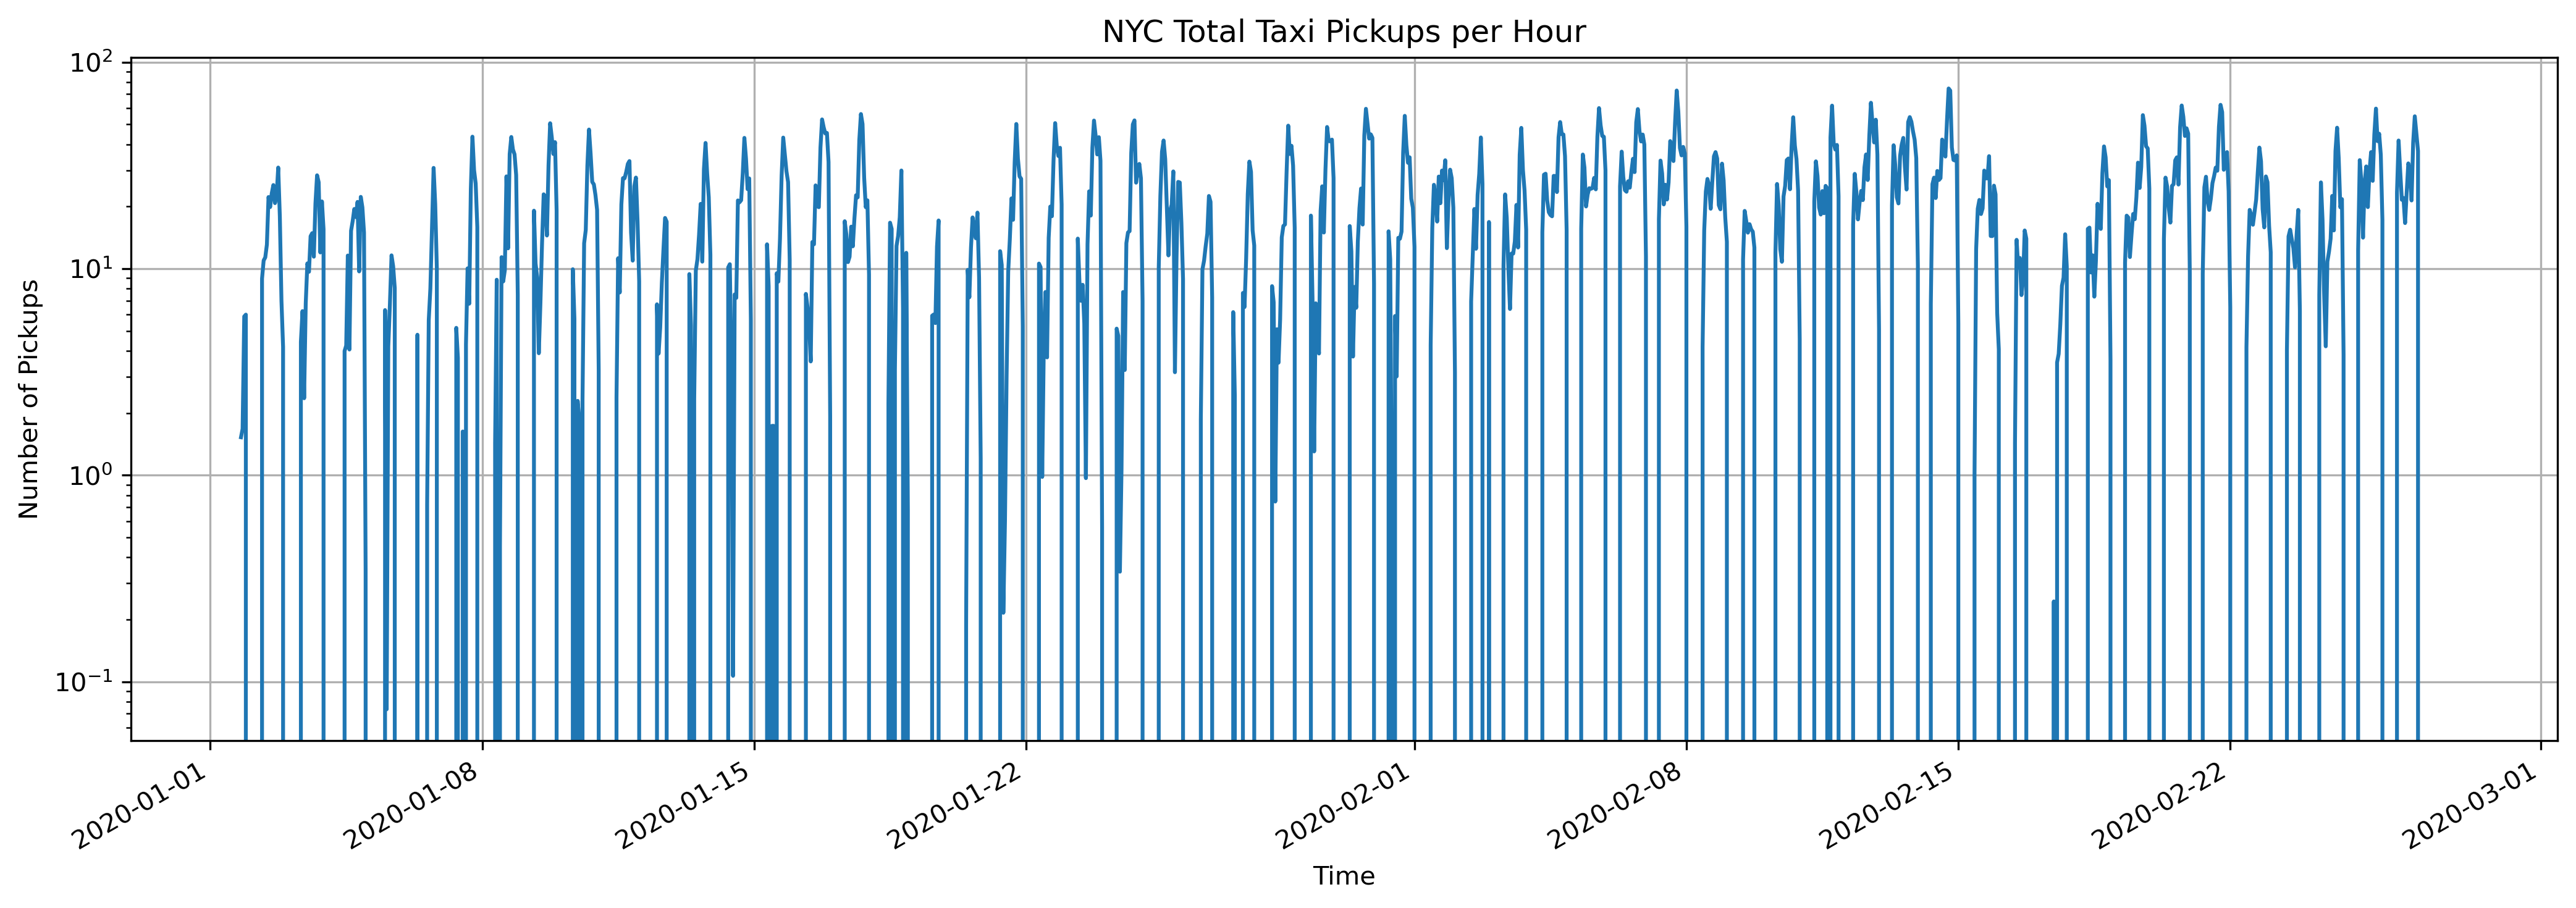

In [7]:
# Aggregate over all zones for initial pattern
total_hourly_demand = demand.groupby("pickup_hour")["trip_count"].sum()

plt.figure(figsize=(14, 5), dpi=300)
total_hourly_demand.plot()
plt.title("NYC Total Taxi Pickups per Hour")
plt.xlabel("Time")
plt.ylabel("Number of Pickups")
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

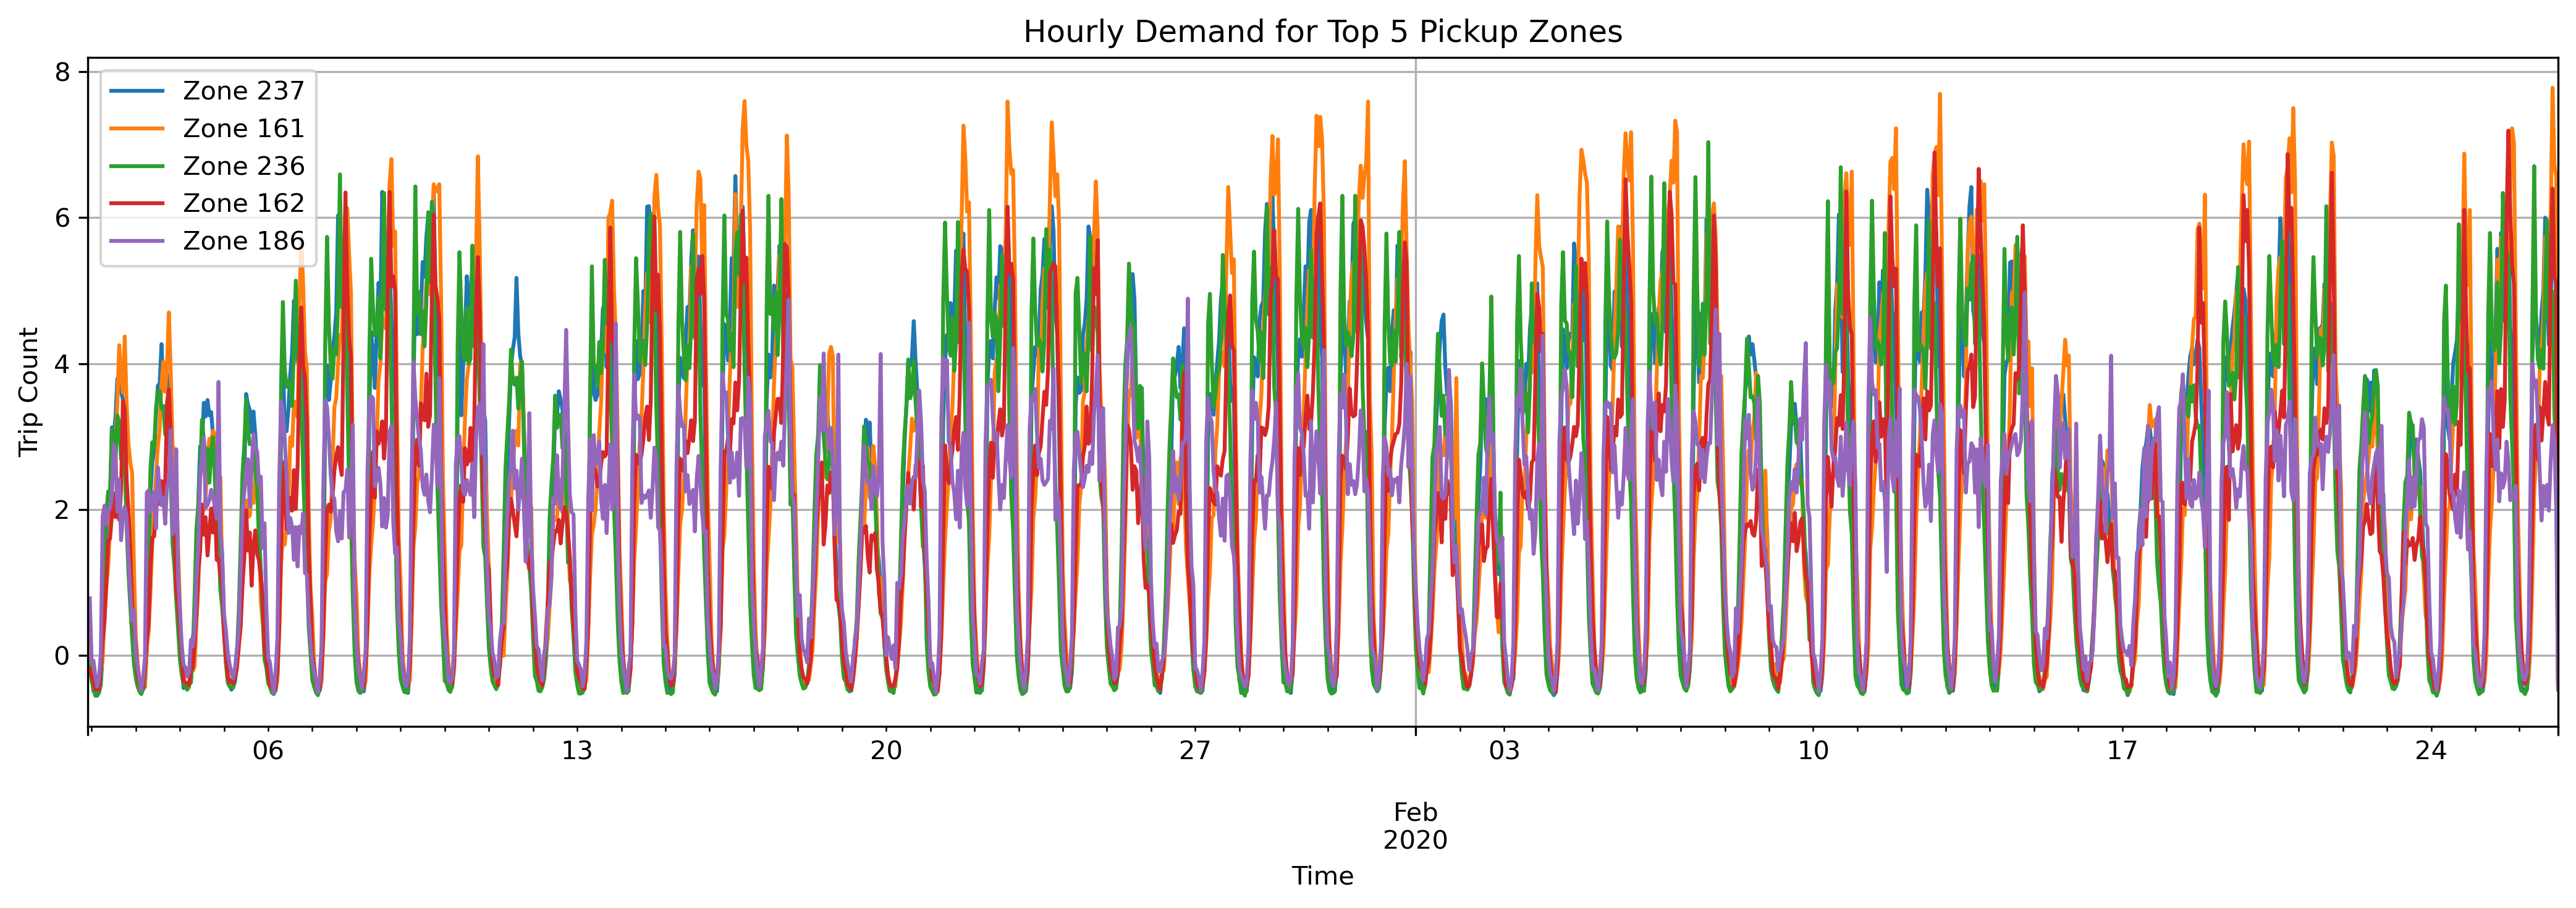

In [8]:
# Top 5 most active pickup zones
top_zones = demand.groupby("PULocationID")["trip_count"].sum().nlargest(5).index

plt.figure(figsize=(14, 5), dpi=300)
for zone_id in top_zones:
    zone_series = demand[demand["PULocationID"] == zone_id].set_index("pickup_hour").resample("h")["trip_count"].sum()
    zone_series.plot(label=f"Zone {zone_id}")

plt.title("Hourly Demand for Top 5 Pickup Zones")
plt.xlabel("Time")
plt.ylabel("Trip Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
